# 1.4 Thyroid disease

## 1.4.1 Load datasets

In [22]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import learning_curve
from scipy.io import loadmat
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Loading the datasets
mat = loadmat("thyroidTrain.mat")
X_train = mat["trainThyroidInput"]
y_train = mat["trainThyroidOutput"]
X_test = mat["testThyroidInput"]

print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("\n\033[1mX_train[:10, :10]:\033[0m\n{}".format(X_train[:10,:10])) #first 10 rows and columns
print("\n\033[1my_train[:5]:\033[0m\n{}".format(y_train[:5])) 
print("\n\033[1mX_test[:10, :10]:\033[0m\n{}".format(X_test[:10, :10]))


X_train shape: (5000, 21)
y_train shape: (5000, 3)
X_test shape: (2200, 21)

X_train[:10, :10]:
[[0.28 0.   1.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.45 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.77 0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [0.72 0.   1.   0.   1.   0.   0.   0.   0.   0.  ]
 [0.78 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.74 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.48 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.51 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.45 1.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.46 1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

y_train[:5]:
[[0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]]

X_test[:10, :10]:
[[0.73 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.6  0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.79 1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.26 0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.71 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.5  1.   1.   0.   0.   0.

# 1.4. 2 Visualization of the data

(5000, 3)
(5000, 2)
(5000,)
(113, 2) (260, 2) (4627, 2)


<IPython.core.display.Javascript object>


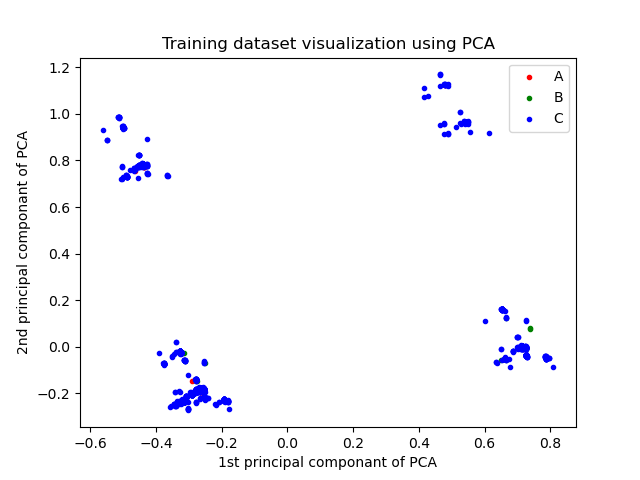

In [2]:
%matplotlib notebook

import matplotlib.pylab as plt
from sklearn.decomposition import PCA

X_pca = PCA(n_components = 2).fit_transform(X_train)
print(y_train.shape)
print(X_pca.shape)
print(np.all(y_train==[0,0,1],axis=1).shape)

X0_pca, X1_pca, X2_pca = X_pca[np.all(y_train==[1,0,0],axis=1)],X_pca[np.all(y_train==[0,1,0],axis=1)],X_pca[np.all(y_train==[0,0,1],axis=1)]
print(X0_pca.shape, X1_pca.shape, X2_pca.shape)

fig, ax = plt.subplots()
ax.scatter(X0_pca[:, 0], X0_pca[:, 1], color = "red", marker=".", label="A")
ax.scatter(X1_pca[:, 0], X1_pca[:, 1], color = "green", marker=".", label="B")
ax.scatter(X2_pca[:, 0], X2_pca[:, 1], color = "blue", marker=".", label="C")

ax.set_xlabel("1st principal componant of PCA")
ax.set_ylabel("2nd principal componant of PCA")
ax.set_title("Training dataset visualization using PCA")
ax.legend()
fig.show()


# 1.4. 3 Feature Selection
Decide the amount/which features are to be used and "discarding" irrelevant features, normalization is required when there are big differences in the ranges of different features which is not in this case, theirfor we are not normalizing the data.

<IPython.core.display.Javascript object>


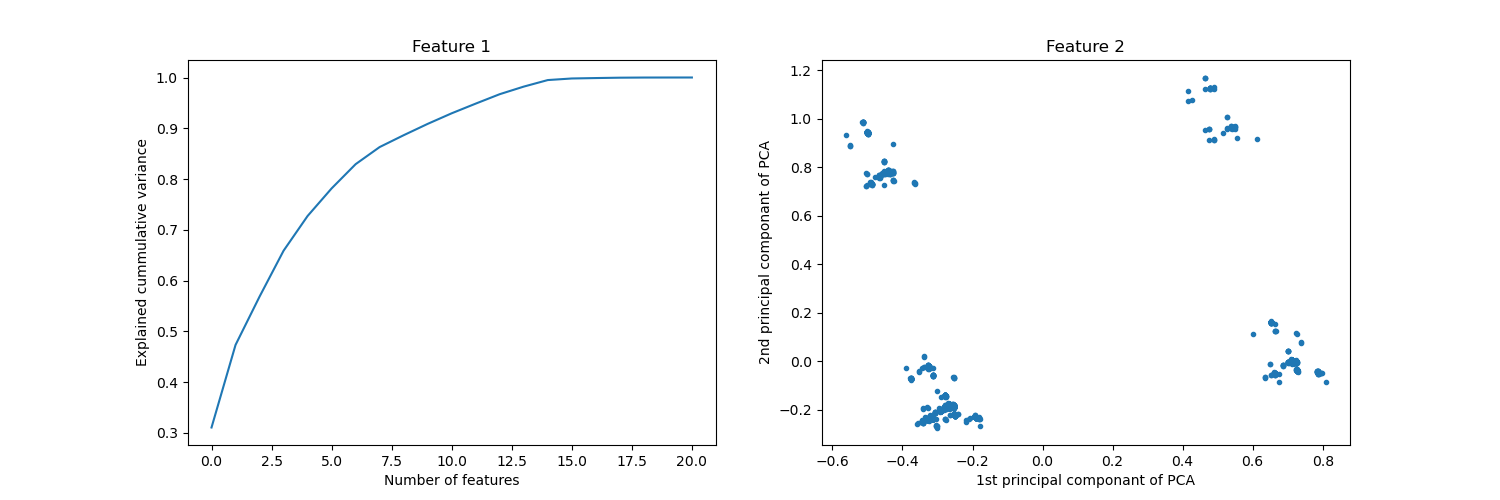


Explained cummulative variance: 
[0.31036517 0.47305845 0.5682959  0.65872494 0.72713443 0.78145833
 0.8292298  0.86294449 0.88628028 0.90862631 0.9294811  0.94855301
 0.96713435 0.9820668  0.99495111 0.99807096 0.99890497 0.99962711
 0.99991214 0.99996986 1.        ]

Explained variance: 
[3.10365172e-01 1.62693274e-01 9.52374546e-02 9.04290340e-02
 6.84094903e-02 5.43239080e-02 4.77714635e-02 3.37146918e-02
 2.33357954e-02 2.23460306e-02 2.08547841e-02 1.90719100e-02
 1.85813377e-02 1.49324564e-02 1.28843058e-02 3.11985427e-03
 8.34003021e-04 7.22146144e-04 2.85027611e-04 5.77160046e-05
 3.01441677e-05]


Text(0, 0.5, '2nd principal componant of PCA')

In [3]:
pca = PCA().fit(X_train)
fig1, ax1 = fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax1[0].plot(np.cumsum(pca.explained_variance_ratio_))
print("\n\033[1mExplained cummulative variance:\033[0m \n{}".format(np.cumsum(pca.explained_variance_ratio_)))
print("\n\033[1mExplained variance:\033[0m \n{}".format(pca.explained_variance_ratio_))
ax1[0].set_title('Feature 1')
ax1[0].set_xlabel("Number of features")
ax1[0].set_ylabel("Explained cummulative variance")

X_train_pca = pca.transform(X_train)
ax1[1].scatter(X_train_pca[:,0], X_train_pca[:,1], marker=".")
ax1[1].set_title('Feature 2')
ax1[1].set_xlabel('1st principal componant of PCA')
ax1[1].set_ylabel('2nd principal componant of PCA')

# 1.4. 4 Data normalization
Normalization is required when there are big differences in the ranges of different features which is not in this case, theirfor we are not normalizing the data.

# 1.4. 4 K-Nearest Neighbors
Looking at the result of GridSearchCV using the K-nearest neighbors classifier, we got a pretty good score where the margin between the training and cross-validation scores are pretty small +/- 0,008 (0,8%).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#print(X_train.shape)
#print(y_train.shape)

#Parameters to pass in to the grid
param_grid = [{'n_neighbors':list(range(1, 31)),
               'weights':['uniform'],
               'algorithm':['ball_tree', 'kd_tree', 'brute'],
               'leaf_size':[30],
               'p':[1,2,3],
               'metric':['minkowski', 'euclidean', 'manhattan', 'chebyshev', 'seuclidean', 'mahalanobis'],
               'metric_params':[None],
               'n_jobs':[-1]
              }]

# instantiating the model
knn = KNeighborsClassifier()

# Using gridsearch with 10-fold corssvalidation (cv=10) with k-range from 1-31
print('Training the KNN, this might take some time..')
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', n_jobs=-1)

# fit the grid with training data
grid.fit(X_train, y_train)

# Single best score achieved across all parameters (k)
print ('\n\033[1mSingel best score within k 1 to 30: \033[0m \n{}'.format(grid.best_score_))

# Actual model object fit with those best parameters
clf = grid.best_estimator_

print ('\n\033[1mBest parameters of the KNN are following: \033[0m \n{}'.format(grid.best_params_))
print()

Training the KNN, this might take some time..

Singel best score within k 1 to 30:  
0.9472000000000002

Best parameters of the KNN are following:  
{'algorithm': 'brute', 'leaf_size': 30, 'metric': 'seuclidean', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}



# 1.4. 4.1. Evaluation of KNN results
Looking at the result of GridSearchCV from previous section and the learning curve (figure down below), it's somewhat ambiguous and can be miss interpreted, but we got a pretty good score where the margin between the training and cross-validation scores are pretty small +/- 0,008 (0,8%). The modell tend not to overfit neither underfit. 

0.947 (+/- 0.008)


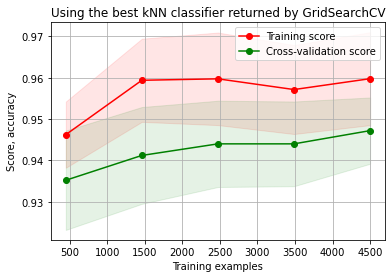

In [10]:
train_sizes, train_scores, test_scores = learning_curve(clf, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best kNN classifier returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, accuracy")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()

# 1.4 4.2 Random Forest Classifier

In [71]:
#Parameters to pass in to the grid
param_grid = [{'n_estimators':[100, 200, 300, 1000], 
               'criterion':['gini', 'entropy'],
               'max_depth':[80, 90, 100, 110, None],
               'min_samples_split': [8, 10, 12],
               'max_features':['sqrt', 'log2'],
               'min_samples_leaf':[3, 4, 5],
               'min_weight_fraction_leaf':[0],
               'bootstrap':[True],
              }]

rfc = RandomForestClassifier()
print('Training the RFC please be patient, this might take some time...')
grid = GridSearchCV(rfc, param_grid, cv=10, n_jobs=-1, verbose = 2)

# fit the grid with training data
grid.fit(X_train, y_train)

pred=grid.predict(X_test)

# Single best score achieved across all parameters
print ('\n\033[1mSingel best score: \033[0m \n{}'.format(grid.best_score_))

# Actual model object fit with those best parameters
clf = grid.best_estimator_
#Summerize result
print ('\n\033[1mBest parameters of the Random Forest Classifier are following: \033[0m \n{}'.format(grid.best_params_))



#means = grid.cv_results_['mean_test_score']
#stds = grid.cv_results_['std_test_score']
#params = grid.cv_results_['params']


Training the RFC please be patient, this might take some time...
Fitting 10 folds for each of 720 candidates, totalling 7200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed:   49.1s
[Parallel(n_jobs=-1)]: Done 624 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 989 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 1434 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 1961 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 2568 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 3257 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 4877 tasks      | elapsed: 11.9min
[Parallel(n_jobs=-1)]: Done 5808 tasks      | elapsed: 14.3min
[Parallel(n_jobs=-1)]: Done 6821 tasks      | elapsed: 16.9min
[Parallel(n_jobs=-1)]: Done 7200 out of 7200 | elapsed: 17.9min finished



Singel best score:  
0.9934000000000001

Best parameters of the Random Forest Classifier are following:  
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': 100, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'min_weight_fraction_leaf': 0, 'n_estimators': 100}
